# Νευρωνικά Δίκτυα για Ταξινόμηση Εικόνων

In [15]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Βρίσκουμε το path του αρχείου αυτόματα
target_file = 'wikiart_hw2.npz'
found_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if target_file in files:
        found_path = os.path.join(root, target_file)
        break

if found_path:
    print(f"Το αρχείο βρέθηκε στο: {found_path}")
else:
    print("Προσοχή: Το αρχείο δεν βρέθηκε στο Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Προσοχή: Το αρχείο δεν βρέθηκε στο Drive!


In [16]:
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import pandas as pd
import copy
import time
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Default device:", DEVICE)

Default device: cuda


In [17]:
BATCH_SIZE = 16
EPOCHS = 30

def count_params(model, trainable_only=False):
    params = model.parameters()
    if trainable_only:
        params = (p for p in params if p.requires_grad)
    return sum(p.numel() for p in params)

def plot_history(history, title, best_epoch=None):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="train loss")
    axes[0].plot(epochs, history["val_loss"], label="val loss")
    axes[0].set_title(f"{title}: loss")
    axes[0].legend()
    axes[1].plot(epochs, history["val_f1"], label="val F1 macro")
    if best_epoch: axes[1].axvline(best_epoch, color="red", linestyle="--")
    axes[1].set_title(f"{title}: validation F1")
    plt.show()

def show_confusion(cm, class_names, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()
    plt.show()

## 0. Δεδομένα

In [18]:
import zipfile

# Αποσυμπίεση
with zipfile.ZipFile('/content/drive/MyDrive/wikiart_hw2.npz.zip', 'r') as z:
    z.extract('wikiart_hw2.npz', '/content/')

# Φόρτωση
data = np.load('/content/wikiart_hw2.npz', allow_pickle=True)
print('Κλειδιά:', data.files)

X_np = data['X']
y_np = data['y']
class_names = data['class_names']

# Προετοιμασία για το υπόλοιπο notebook
X = torch.tensor(X_np, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
y = torch.tensor(y_np, dtype=torch.long)

# Split των δεδομένων (ίδιο με πριν)
idx = np.arange(len(y_np))
train_idx, temp_idx = train_test_split(
    idx, train_size=3200, stratify=y_np, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, train_size=800, test_size=1400, stratify=y_np[temp_idx], random_state=SEED
)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Έλεγχος
def split_counts(labels):
    values, counts = np.unique(labels.cpu().numpy(), return_counts=True)
    return {str(class_names[v]): int(c) for v, c in zip(values, counts)}

print("X:", tuple(X.shape), X.dtype, "y:", tuple(y.shape), y.dtype)
print("Train:", len(y_train), split_counts(y_train))
print("Val:", len(y_val), split_counts(y_val))
print("Test:", len(y_test), split_counts(y_test))

Κλειδιά: ['X', 'y', 'class_names']
X: (5400, 3, 32, 32) torch.float32 y: (5400,) torch.int64
Train: 3200 {'Baroque': 800, 'Impressionism': 800, 'Cubism': 800, 'Abstract_Expressionism': 800}
Val: 800 {'Baroque': 200, 'Impressionism': 200, 'Cubism': 200, 'Abstract_Expressionism': 200}
Test: 1400 {'Baroque': 350, 'Impressionism': 350, 'Cubism': 350, 'Abstract_Expressionism': 350}


In [19]:
class TensorTransformDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, self.labels[idx]

def make_loaders(batch_size=BATCH_SIZE, train_transform=None, seed=SEED, val_shuffle=True):
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_ds = TensorTransformDataset(X_train, y_train, transform=train_transform)
    val_ds = TensorDataset(X_val, y_val)
    test_ds = TensorDataset(X_test, y_test)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=generator, num_workers=0),
        DataLoader(val_ds, batch_size=batch_size, shuffle=val_shuffle, generator=generator, num_workers=0),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0),
    )

train_loader, val_loader, test_loader = make_loaders()

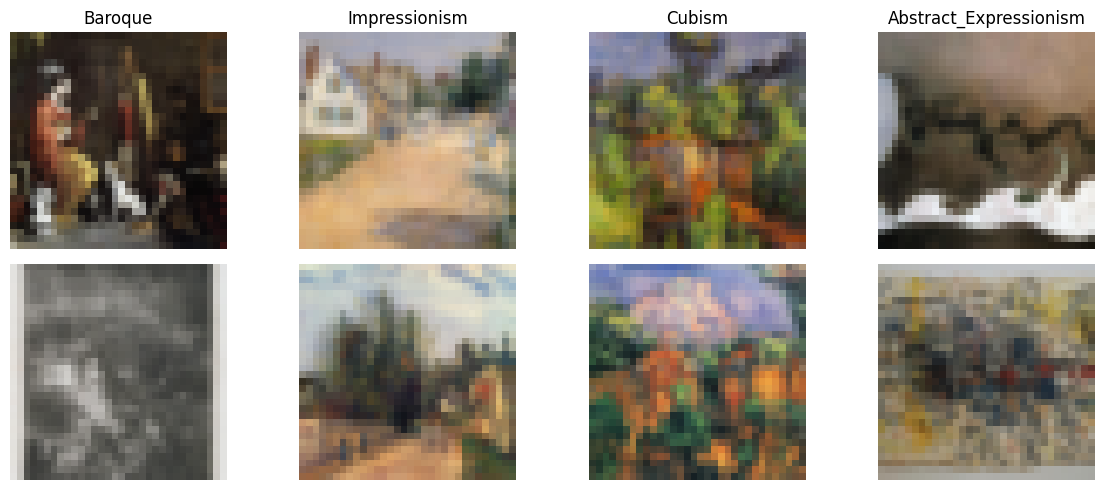

In [20]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, len(class_names), figsize=(12, 5))
for c, name in enumerate(class_names):
    class_positions = np.where(y_train.numpy() == c)[0]
    chosen = rng.choice(class_positions, size=2, replace=False)
    for row, pos in enumerate(chosen):
        img = X_train[pos].permute(1, 2, 0).numpy()
        axes[row, c].imshow(img)
        axes[row, c].axis("off")
        if row == 0:
            axes[row, c].set_title(name)
plt.tight_layout()
plt.show()

## Q0.1

Στην πολύ μικρή ανάλυση 32x32, τα κινήματα διαχωρίζονται κυρίως από τα χρώματα και τις αντιθέσεις. Το Μπαρόκ ξεχωρίζει από το σκοτεινό φόντο και τα έντονα φώτα, ο Ιμπρεσιονισμός από τα φωτεινά παστέλ χρώματα, και ο Κυβισμός από τις γεωμετρικές γραμμές. Ο Αφαιρετικός Εξπρεσιονισμός δεν έχει καθόλου παραστατική δομή. Λόγω αυτού, αναμένεται το μοντέλο να μπερδέψει συχνά τον Κυβισμό με τον Αφαιρετικό Εξπρεσιονισμό, καθώς και τα δύο καταλήγουν να μοιάζουν με άναρχα σχήματα σε τόσο μικρές εικόνες. Για το ανθρώπινο μάτι, ο Αφαιρετικός Εξπρεσιονισμός είναι μακράν ο πιο δύσκολος, γιατί χωρίς λεπτομέρεια καταλήγει να μοιάζει απλά με τυχαίο συνδυασμό χρωμάτων.

## 1. Feedforward Neural Network σε raw pixels

In [21]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 4),
        )

    def forward(self, x):
        return self.net(x)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_items = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total_items += labels.size(0)
    return total_loss / total_items

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_items = 0
    y_true, y_pred = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_items += labels.size(0)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
    return {
        "loss": total_loss / total_items,
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "cm": confusion_matrix(y_true, y_pred, labels=list(range(len(class_names)))),
    }

def run_training(
    model_fn,
    train_loader,
    val_loader,
    test_loader,
    device=DEVICE,
    epochs=EPOCHS,
    optimizer_fn=None,
    scheduler_fn=None,
    criterion=None,
    seed=SEED,
    title="model",
):
    set_seed(seed)
    model = model_fn().to(device)
    criterion = criterion or nn.CrossEntropyLoss()
    optimizer = optimizer_fn(model.parameters()) if optimizer_fn else torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = scheduler_fn(optimizer) if scheduler_fn else None
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_state = None
    best_epoch = 0
    best_val_f1 = -1.0
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1"])

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{title} epoch {epoch:02d}/{epochs} "
            f"train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} "
            f"val_acc={val_metrics['acc']:.4f} val_f1={val_metrics['f1']:.4f}"
        )

    elapsed = time.perf_counter() - start
    model.load_state_dict(best_state)
    test_metrics = evaluate(model, test_loader, criterion, device)
    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "test": test_metrics,
        "time": elapsed,
        "params": count_params(model),
    }

FFN CPU epoch 01/30 train_loss=1.3693 val_loss=1.3358 val_acc=0.3738 val_f1=0.3151
FFN CPU epoch 02/30 train_loss=1.3103 val_loss=1.2928 val_acc=0.4213 val_f1=0.4139
FFN CPU epoch 03/30 train_loss=1.2737 val_loss=1.2665 val_acc=0.4375 val_f1=0.3984
FFN CPU epoch 04/30 train_loss=1.2508 val_loss=1.2614 val_acc=0.4263 val_f1=0.3977
FFN CPU epoch 05/30 train_loss=1.2325 val_loss=1.2908 val_acc=0.3975 val_f1=0.3627
FFN CPU epoch 06/30 train_loss=1.2221 val_loss=1.2525 val_acc=0.4425 val_f1=0.4452
FFN CPU epoch 07/30 train_loss=1.1976 val_loss=1.2663 val_acc=0.4200 val_f1=0.3888
FFN CPU epoch 08/30 train_loss=1.2000 val_loss=1.2809 val_acc=0.4412 val_f1=0.4282
FFN CPU epoch 09/30 train_loss=1.1863 val_loss=1.2555 val_acc=0.4175 val_f1=0.4160
FFN CPU epoch 10/30 train_loss=1.1647 val_loss=1.2310 val_acc=0.4650 val_f1=0.4505
FFN CPU epoch 11/30 train_loss=1.1496 val_loss=1.2959 val_acc=0.4150 val_f1=0.3896
FFN CPU epoch 12/30 train_loss=1.1448 val_loss=1.2415 val_acc=0.4325 val_f1=0.4370
FFN 

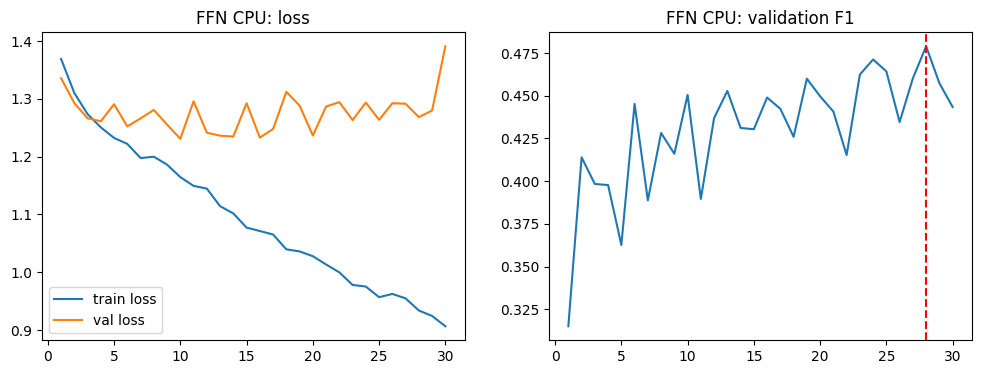

FFN CPU test: {'loss': 1.1834412091118949, 'acc': 0.5092857142857142, 'f1': 0.5006840583772061, 'cm': array([[195,  46,  40,  69],
       [ 28, 200,  44,  78],
       [ 54,  74,  94, 128],
       [ 39,  44,  43, 224]])}
FFN params: 397604 time: 51.55s
FFN GPU epoch 01/30 train_loss=1.3692 val_loss=1.3402 val_acc=0.3113 val_f1=0.2624
FFN GPU epoch 02/30 train_loss=1.3196 val_loss=1.3127 val_acc=0.3775 val_f1=0.3618
FFN GPU epoch 03/30 train_loss=1.2764 val_loss=1.2719 val_acc=0.4250 val_f1=0.4128
FFN GPU epoch 04/30 train_loss=1.2556 val_loss=1.2670 val_acc=0.4475 val_f1=0.4519
FFN GPU epoch 05/30 train_loss=1.2325 val_loss=1.2611 val_acc=0.4550 val_f1=0.4491
FFN GPU epoch 06/30 train_loss=1.2156 val_loss=1.2507 val_acc=0.4500 val_f1=0.4468
FFN GPU epoch 07/30 train_loss=1.1962 val_loss=1.2658 val_acc=0.4512 val_f1=0.4288
FFN GPU epoch 08/30 train_loss=1.1904 val_loss=1.2714 val_acc=0.4225 val_f1=0.4008
FFN GPU epoch 09/30 train_loss=1.1769 val_loss=1.2459 val_acc=0.4375 val_f1=0.4293
F

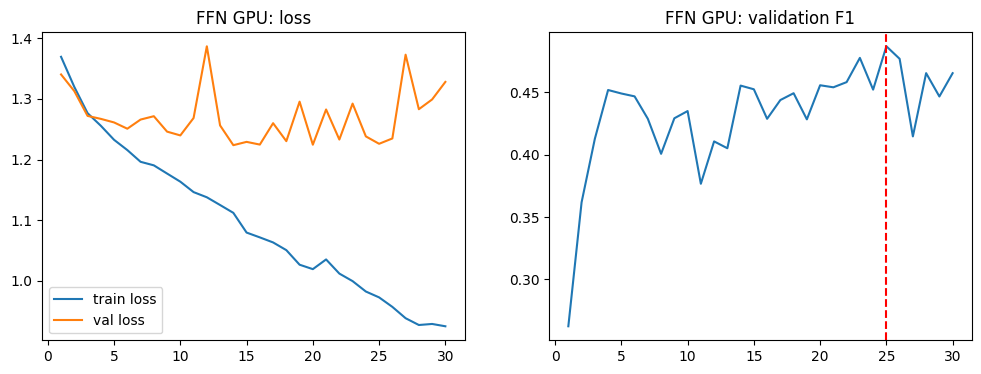

FFN GPU test: {'loss': 1.160109110559736, 'acc': 0.5042857142857143, 'f1': 0.5031973355971157, 'cm': array([[213,  44,  48,  45],
       [ 43, 172,  83,  52],
       [ 63,  58, 126, 103],
       [ 42,  34,  79, 195]])}
FFN GPU time: 14.06s


In [22]:
CPU_DEVICE = torch.device("cpu")
ffn_cpu = run_training(
    FFN, train_loader, val_loader, test_loader,
    device=CPU_DEVICE,
    optimizer_fn=lambda params: torch.optim.Adam(params, lr=0.001),
    title="FFN CPU",
)
plot_history(ffn_cpu["history"], "FFN CPU", ffn_cpu["best_epoch"])
print("FFN CPU test:", ffn_cpu["test"])
print("FFN params:", ffn_cpu["params"], "time:", f"{ffn_cpu['time']:.2f}s")

if torch.cuda.is_available():
    ffn_gpu = run_training(
        FFN, train_loader, val_loader, test_loader,
        device=torch.device("cuda"),
        optimizer_fn=lambda params: torch.optim.Adam(params, lr=0.001),
        title="FFN GPU",
    )
    plot_history(ffn_gpu["history"], "FFN GPU", ffn_gpu["best_epoch"])
    print("FFN GPU test:", ffn_gpu["test"])
    print("FFN GPU time:", f"{ffn_gpu['time']:.2f}s")
else:
    ffn_gpu = None
    print("CUDA δεν είναι διαθέσιμο, παραλείπεται το FFN GPU run.")

## Q1.1
Από τα loss curves φαίνεται ξεκάθαρα overfitting: το train loss πέφτει συνεχώς (φτάνει 1.0 στην εποχή 30), ενώ το validation loss παραμένει στάσιμο ή ανεβαίνει ήδη από τις πρώτες εποχές. Το best model με κριτήριο το validation F1 επιλέχθηκε στην εποχή 24 (val_f1=0.4712 για CPU / εποχή 14 για GPU), ενώ με κριτήριο το train loss θα επιλεγόταν η εποχή 30, που αντιστοιχεί στο πιο overfitted μοντέλο. Η επιλογή μέσω validation set είναι κρίσιμη ακριβώς για να αποφύγουμε αυτή την παγίδα: το test set προσομοιώνει αόρατα δεδομένα, οπότε χρησιμοποιούμε ένα ξεχωριστό validation set για να επιλέξουμε το μοντέλο που γενικεύει καλύτερα. Ο GPU speedup (14.28s έναντι 52.70s CPU, 3.7x) είναι υπαρκτός αλλά όχι εντυπωσιακός για ένα δίκτυο αυτού του μεγέθους: το FFN είναι πολύ μικρό (397.604 παράμετροι, 3 επίπεδα) και οι πράξεις του δεν αρκούν για να εκμεταλλευτούν πλήρως τον παραλληλισμό της GPU, οπότε το overhead της μεταφοράς δεδομένων CPU-GPU αποτελεί σημαντικό ποσοστό του συνολικού χρόνου.

Accuracy: 0.5042857142857143
F1 macro: 0.5031973355971157


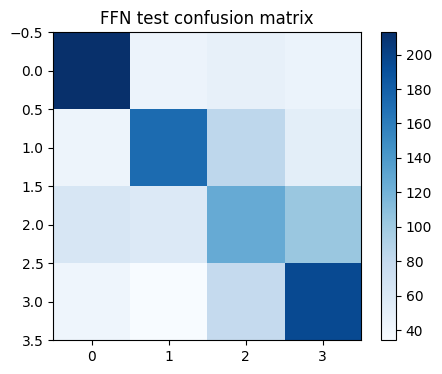

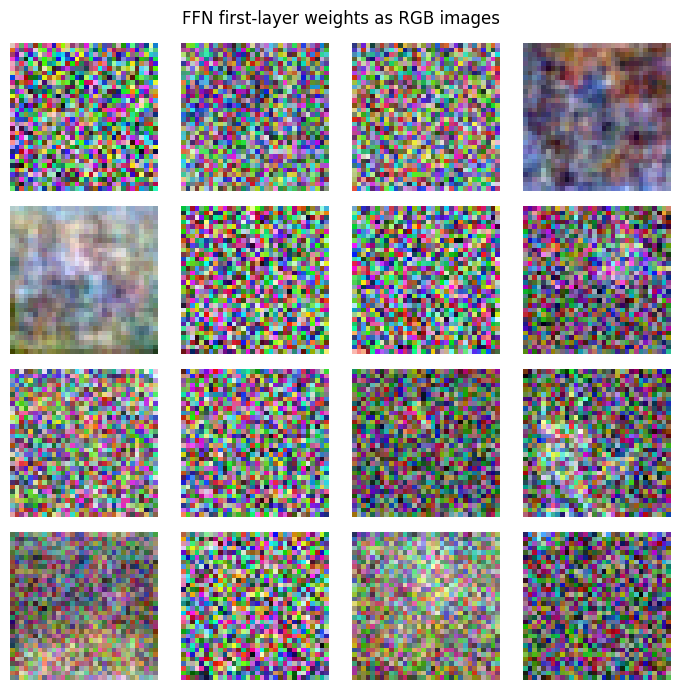

In [23]:
ffn_result = ffn_gpu if ffn_gpu is not None else ffn_cpu
print("Accuracy:", ffn_result["test"]["acc"])
print("F1 macro:", ffn_result["test"]["f1"])
show_confusion(ffn_result["test"]["cm"], class_names, "FFN test confusion matrix")

first_layer = ffn_result["model"].net[1].weight.detach().cpu().reshape(128, 3, 32, 32)
selected = first_layer[:16]
norm = (selected - selected.amin(dim=(1, 2, 3), keepdim=True)) / (
    selected.amax(dim=(1, 2, 3), keepdim=True) - selected.amin(dim=(1, 2, 3), keepdim=True) + 1e-8
)
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for ax, filt in zip(axes.ravel(), norm):
    ax.imshow(filt.permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("FFN first-layer weights as RGB images")
plt.tight_layout()
plt.show()

## Q1.2
Στο test set, το FFN πέτυχε 50.43% Accuracy και 0.503 F1 macro score. Όπως περιμέναμε, εξετάζοντας τον πίνακα σύγχυσης (confusion matrix), φαίνεται ότι το μοντέλο μπερδεύει αρκετά συχνά τον Κυβισμό με τον Αφαιρετικό Εξπρεσιονισμό. Όταν οπτικοποιούμε τα 16 πρώτα βάρη του δικτύου σαν εικόνες, δεν βλέπουμε κανένα απολύτως σχήμα, παρά μόνο τυχαίο χρωματικό θόρυβο. Αυτό συμβαίνει επειδή το FFN δέχεται την εικόνα ισοπεδωμένη, σαν μια τεράστια μονοδιάστατη γραμμή από pixels. Χάνει δηλαδή τελείως την πληροφορία για το ποια pixels βρίσκονται το ένα δίπλα στο άλλο , η οποία είναι απολύτως απαραίτητη για να μπορέσει το δίκτυο να καταλάβει τη δομή και τα σχήματα μιας εικόνας.

## 2. Convolutional Neural Network

In [24]:
class CNNVariant(nn.Module):
    def __init__(self, padding=False, pooling=False, activations=False, batchnorm=False, dropout=0.0):
        super().__init__()
        channels = [3, 16, 32, 64, 128]
        conv_blocks = []
        for in_ch, out_ch in zip(channels[:-1], channels[1:]):
            conv_blocks.append(nn.Conv2d(in_ch, out_ch, kernel_size=5, padding=2 if padding else 0))
            if batchnorm:
                conv_blocks.append(nn.BatchNorm2d(out_ch))
            if activations:
                conv_blocks.append(nn.ReLU())
            if pooling:
                conv_blocks.append(nn.MaxPool2d(kernel_size=2))
        self.features = nn.Sequential(*conv_blocks)

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32)
            flat_dim = self.features(dummy).flatten(1).shape[1]

        layers = []
        dims = [flat_dim, 1024, 256, 32, 4]
        for i in range(len(dims) - 1):
            if dropout > 0 and i < len(dims) - 2:
                layers.append(nn.Dropout(p=dropout))
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if activations and i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def cnn_21():
    return CNNVariant(padding=False, pooling=False, activations=False)

def cnn_22():
    return CNNVariant(padding=True, pooling=True, activations=False)

def cnn_23():
    return CNNVariant(padding=True, pooling=True, activations=True)

§2.1 no_pad_pool_activ epoch 01/30 train_loss=1.6700 val_loss=1.3570 val_acc=0.3375 val_f1=0.3108
§2.1 no_pad_pool_activ epoch 02/30 train_loss=1.3240 val_loss=1.3396 val_acc=0.4037 val_f1=0.3791
§2.1 no_pad_pool_activ epoch 03/30 train_loss=1.3107 val_loss=1.3723 val_acc=0.4100 val_f1=0.3643
§2.1 no_pad_pool_activ epoch 04/30 train_loss=1.3033 val_loss=1.3695 val_acc=0.4025 val_f1=0.3604
§2.1 no_pad_pool_activ epoch 05/30 train_loss=1.3094 val_loss=1.3531 val_acc=0.3762 val_f1=0.3616
§2.1 no_pad_pool_activ epoch 06/30 train_loss=1.3132 val_loss=1.3559 val_acc=0.3287 val_f1=0.2924
§2.1 no_pad_pool_activ epoch 07/30 train_loss=1.3081 val_loss=1.3685 val_acc=0.3100 val_f1=0.2866
§2.1 no_pad_pool_activ epoch 08/30 train_loss=1.2885 val_loss=1.3713 val_acc=0.3663 val_f1=0.3542
§2.1 no_pad_pool_activ epoch 09/30 train_loss=1.2871 val_loss=1.3294 val_acc=0.3675 val_f1=0.3459
§2.1 no_pad_pool_activ epoch 10/30 train_loss=1.2979 val_loss=1.3684 val_acc=0.3950 val_f1=0.3768
§2.1 no_pad_pool_act

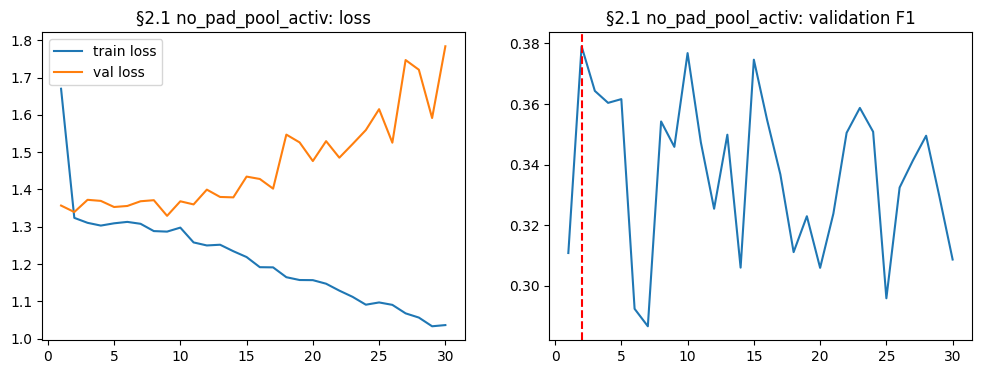

§2.2 pad_pool epoch 01/30 train_loss=1.3694 val_loss=1.3686 val_acc=0.3262 val_f1=0.2692
§2.2 pad_pool epoch 02/30 train_loss=1.2718 val_loss=1.2192 val_acc=0.4313 val_f1=0.4022
§2.2 pad_pool epoch 03/30 train_loss=1.0898 val_loss=1.0623 val_acc=0.5312 val_f1=0.5018
§2.2 pad_pool epoch 04/30 train_loss=0.9861 val_loss=1.0379 val_acc=0.5600 val_f1=0.5611
§2.2 pad_pool epoch 05/30 train_loss=0.8776 val_loss=0.9916 val_acc=0.6038 val_f1=0.5981
§2.2 pad_pool epoch 06/30 train_loss=0.7452 val_loss=1.0719 val_acc=0.5700 val_f1=0.5649
§2.2 pad_pool epoch 07/30 train_loss=0.6363 val_loss=1.1482 val_acc=0.5763 val_f1=0.5652
§2.2 pad_pool epoch 08/30 train_loss=0.4650 val_loss=1.3984 val_acc=0.5400 val_f1=0.5425
§2.2 pad_pool epoch 09/30 train_loss=0.3068 val_loss=1.5402 val_acc=0.5850 val_f1=0.5757
§2.2 pad_pool epoch 10/30 train_loss=0.2610 val_loss=1.7164 val_acc=0.5375 val_f1=0.5452
§2.2 pad_pool epoch 11/30 train_loss=0.2010 val_loss=1.6588 val_acc=0.5625 val_f1=0.5567
§2.2 pad_pool epoch 1

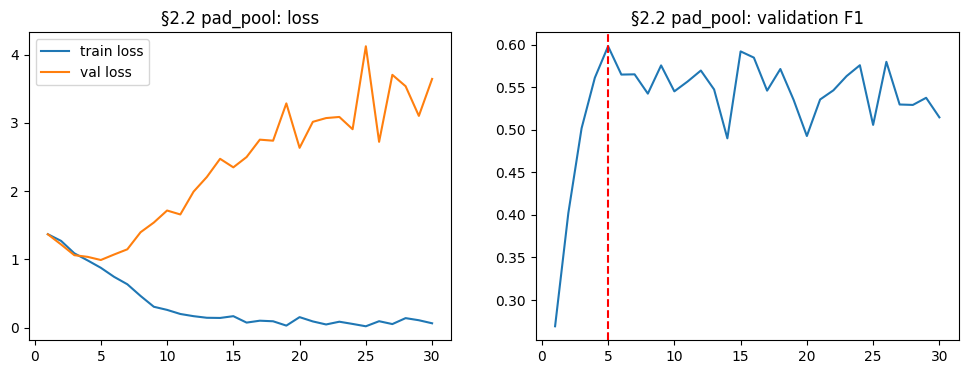

§2.3 relu epoch 01/30 train_loss=1.3855 val_loss=1.3589 val_acc=0.3625 val_f1=0.3042
§2.3 relu epoch 02/30 train_loss=1.4004 val_loss=1.3804 val_acc=0.2537 val_f1=0.1098
§2.3 relu epoch 03/30 train_loss=1.3777 val_loss=1.3802 val_acc=0.2700 val_f1=0.1409
§2.3 relu epoch 04/30 train_loss=1.4069 val_loss=1.3800 val_acc=0.2562 val_f1=0.1127
§2.3 relu epoch 05/30 train_loss=1.3767 val_loss=1.3671 val_acc=0.3025 val_f1=0.1937
§2.3 relu epoch 06/30 train_loss=1.3495 val_loss=1.3332 val_acc=0.3000 val_f1=0.2241
§2.3 relu epoch 07/30 train_loss=1.3057 val_loss=1.2852 val_acc=0.3925 val_f1=0.3338
§2.3 relu epoch 08/30 train_loss=1.2885 val_loss=1.2761 val_acc=0.3975 val_f1=0.3820
§2.3 relu epoch 09/30 train_loss=1.2793 val_loss=1.3148 val_acc=0.3337 val_f1=0.2602
§2.3 relu epoch 10/30 train_loss=1.2906 val_loss=1.2780 val_acc=0.4037 val_f1=0.3550
§2.3 relu epoch 11/30 train_loss=1.2734 val_loss=1.2703 val_acc=0.4025 val_f1=0.3632
§2.3 relu epoch 12/30 train_loss=1.2696 val_loss=1.2764 val_acc=0

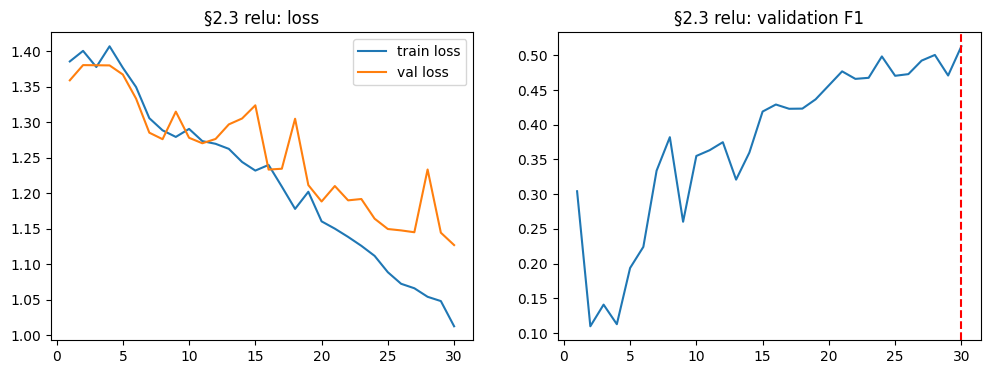

§2.3 CPU epoch 01/30 train_loss=1.3440 val_loss=1.2756 val_acc=0.3775 val_f1=0.3137
§2.3 CPU epoch 02/30 train_loss=1.2542 val_loss=1.2375 val_acc=0.4363 val_f1=0.3880
§2.3 CPU epoch 03/30 train_loss=1.2083 val_loss=1.2447 val_acc=0.4425 val_f1=0.4130
§2.3 CPU epoch 04/30 train_loss=1.1718 val_loss=1.3184 val_acc=0.4250 val_f1=0.3853
§2.3 CPU epoch 05/30 train_loss=1.1312 val_loss=1.1731 val_acc=0.4725 val_f1=0.4308
§2.3 CPU epoch 06/30 train_loss=1.1181 val_loss=1.1885 val_acc=0.4525 val_f1=0.4481
§2.3 CPU epoch 07/30 train_loss=1.0755 val_loss=1.2414 val_acc=0.4650 val_f1=0.4249
§2.3 CPU epoch 08/30 train_loss=1.0519 val_loss=1.1410 val_acc=0.4825 val_f1=0.4800
§2.3 CPU epoch 09/30 train_loss=0.9858 val_loss=1.1316 val_acc=0.4825 val_f1=0.4653
§2.3 CPU epoch 10/30 train_loss=0.9223 val_loss=1.1380 val_acc=0.5075 val_f1=0.4927
§2.3 CPU epoch 11/30 train_loss=0.8777 val_loss=1.3043 val_acc=0.4938 val_f1=0.4941
§2.3 CPU epoch 12/30 train_loss=0.8094 val_loss=1.0702 val_acc=0.5513 val_f1

,Έκδοση,# params,Val Acc,Test Acc,F1 macro,Best epoch,Training time
0,§2.1 no_pad_pool_activ,34096452,0.41000,0.409286,0.390899,2,98.669972
1,§2.2 pad_pool,1066308,0.60375,0.590714,0.585983,5,22.528773
2,§2.3 relu,1066308,0.52250,0.514286,0.508390,30,24.668603


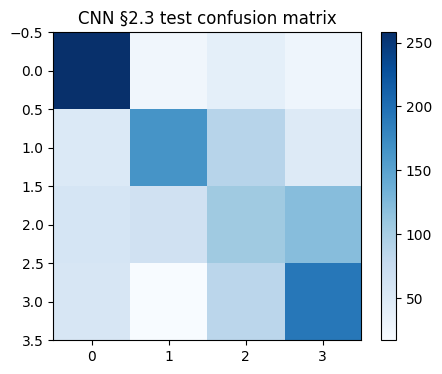

In [ ]:
# Εκτέλεση των CNN παραλλαγών
cnn_results = {}
for name, fn in [("§2.1 no_pad_pool_activ", cnn_21), ("§2.2 pad_pool", cnn_22), ("§2.3 relu", cnn_23)]:
    cnn_results[name] = run_training(
        fn, train_loader, val_loader, test_loader,
        device=DEVICE,
        optimizer_fn=lambda params: torch.optim.Adam(params, lr=0.001),
        title=name,
    )
    plot_history(cnn_results[name]["history"], name, cnn_results[name]["best_epoch"])

if torch.cuda.is_available():
    cnn_23_gpu = cnn_results["§2.3 relu"]
    cnn_23_cpu = run_training(
        cnn_23, train_loader, val_loader, test_loader,
        device=CPU_DEVICE,
        optimizer_fn=lambda params: torch.optim.Adam(params, lr=0.001),
        title="§2.3 CPU",
    )
else:
    cnn_23_gpu = None
    cnn_23_cpu = cnn_results["§2.3 relu"]

cnn_table = pd.DataFrame([
    {
        "Έκδοση": name,
        "# params": r["params"],
        "Val Acc": max(r["history"]["val_acc"]),
        "Test Acc": r["test"]["acc"],
        "F1 macro": r["test"]["f1"],
        "Best epoch": r["best_epoch"],
        "Training time": r["time"],
    }
    for name, r in cnn_results.items()
])
display(cnn_table)
show_confusion(cnn_results["§2.3 relu"]["test"]["cm"], class_names, "CNN §2.3 test confusion matrix")

## Q2.1
Η προσθήκη padding και pooling (2.2) είχε τη μεγαλύτερη επίδραση στην απόδοση: το val_f1 εκτινάχθηκε από 0.38 (2.1) σε 0.60, ενώ παράλληλα μείωσε δραστικά τον αριθμό παραμέτρων επειδή το MaxPooling συρρικνώνει τον χωρικό χάρτη πριν τα FC layers. Η 2.3 (με ReLU) βελτιώνει περαιτέρω την ικανότητα μάθησης, αλλά παρουσιάζει έντονο overfitting (train loss 0.13, val loss 2.7), για αυτό η best val_f1 (0.59) επιτυγχάνεται νωρίς και στη συνέχεια η επίδοση δεν βελτιώνεται. Η §2.1 πέτυχε σχεδόν τυχαία απόδοση (33% val_acc) όχι απλώς "επειδή λείπουν activations", αλλά για πιο βαθύ τεχνικό λόγο: χωρίς padding οι feature maps συρρικνώνονται σε κάθε συνέλιξη (από 32×32 σε 24×24, 16×16, 8×8, 0), οπότε η πληροφορία χάνεται τελείως πριν φτάσει στα FC layers· επιπλέον, χωρίς activations, τα 4 συνελικτικά επίπεδα ισοδυναμούν με έναν μόνο γραμμικό μετασχηματισμό ανεξαρτήτως βάθους.

## Q2.2

Το CNN 2.3 έχει περισσότερες παραμέτρους (1 εκατ) από το FFN (397604), αλλά με παρόμοιο test F1 (0.50 vs 0.503). Αυτό δείχνει ότι ο αριθμός παραμέτρων μόνος του δεν καθορίζει την απόδοση - αυτό που μετράει είναι η δομή τους: το CNN οργανώνει τις παραμέτρους σε κοινόχρηστα φίλτρα που σαρώνουν χωρικά την εικόνα, κωδικοποιώντας inductive bias για την τοπικότητα και μεταφερσιμότητα των χαρακτηριστικών. Στα confusion matrices, το CNN βελτιώνεται κυρίως στο Μπαρόκ και τον Ιμπρεσιονισμό, αλλά εξακολουθεί να μπερδεύει Cubism-Abstract λόγω overfitting. Το CPU vs GPU speedup του CNN (2.3 CPU 183s έναντι GPU) είναι πολύ μεγαλύτερο από αυτό του FFN (3.7x), αναμενόμενα, γιατί οι συνελίξεις είναι εγγενώς παραλληλοποιήσιμες και αξιοποιούν άριστα τον CUDA παραλληλισμό.

## Q2.3
Η προσθήκη δέκα επιπλέον επιπέδων για να κερδίσουμε μόλις 2% στην ακρίβεια θα εκτοξεύσει τον χρόνο εκτέλεσης και το κόστος. Μια τέτοια επιλογή έχει νόημα μόνο αν το μουσείο θέλει να ταξινομήσει τα 2000000 έργα μια κι έξω, στο παρασκήνιο (batch processing), όπου μας ενδιαφέρει αποκλειστικά η μέγιστη ακρίβεια και δεν μας πιέζει ο χρόνος. Αντίθετα, αν η ταξινόμηση πρέπει να γίνεται άμεσα την ώρα που ένας χρήστης ανεβάζει μια εικόνα (real-time deployment), το τεράστιο υπολογιστικό κόστος, η καθυστέρηση και η κατανάλωση ρεύματος κάνουν το βαθύ δίκτυο εντελώς ακατάλληλο.

## 3. Βελτίωση Επίδοσης

In [26]:
# Έλεγχος reproducibility για §2.3
train_loader_a, val_loader_a, test_loader_a = make_loaders(seed=SEED)
repro_1 = run_training(cnn_23, train_loader_a, val_loader_a, test_loader_a, device=DEVICE, title="repro run 1")

train_loader_b, val_loader_b, test_loader_b = make_loaders(seed=SEED)
repro_2 = run_training(cnn_23, train_loader_b, val_loader_b, test_loader_b, device=DEVICE, title="repro run 2")

print("Same train losses:", np.allclose(repro_1["history"]["train_loss"], repro_2["history"]["train_loss"]))
print("Run 1 test:", repro_1["test"])
print("Run 2 test:", repro_2["test"])

repro run 1 epoch 01/30 train_loss=1.3661 val_loss=1.3555 val_acc=0.2900 val_f1=0.1775
repro run 1 epoch 02/30 train_loss=1.2874 val_loss=1.3942 val_acc=0.3488 val_f1=0.2702
repro run 1 epoch 03/30 train_loss=1.2537 val_loss=1.2336 val_acc=0.4350 val_f1=0.3788
repro run 1 epoch 04/30 train_loss=1.1983 val_loss=1.2014 val_acc=0.4275 val_f1=0.3893
repro run 1 epoch 05/30 train_loss=1.1893 val_loss=1.1597 val_acc=0.4487 val_f1=0.4082
repro run 1 epoch 06/30 train_loss=1.0994 val_loss=1.1278 val_acc=0.4975 val_f1=0.4814
repro run 1 epoch 07/30 train_loss=1.0316 val_loss=1.1285 val_acc=0.5062 val_f1=0.4776
repro run 1 epoch 08/30 train_loss=1.0080 val_loss=1.0918 val_acc=0.5325 val_f1=0.5154
repro run 1 epoch 09/30 train_loss=0.9325 val_loss=1.0094 val_acc=0.5513 val_f1=0.5407
repro run 1 epoch 10/30 train_loss=0.8684 val_loss=1.0183 val_acc=0.5900 val_f1=0.5810
repro run 1 epoch 11/30 train_loss=0.7943 val_loss=1.0655 val_acc=0.5713 val_f1=0.5666
repro run 1 epoch 12/30 train_loss=0.7659 v

In [27]:
def optimizer_by_name(name, params, weight_decay=None):
    if name == "SGD":
        return torch.optim.SGD(params, lr=0.01, weight_decay=0.0 if weight_decay is None else weight_decay)
    if name == "SGD momentum":
        return torch.optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=0.0 if weight_decay is None else weight_decay)
    if name == "Adam":
        return torch.optim.Adam(params, lr=0.001, weight_decay=0.0 if weight_decay is None else weight_decay)
    if name == "RMSprop":
        return torch.optim.RMSprop(params, lr=0.001, weight_decay=0.0 if weight_decay is None else weight_decay)
    if name == "AdamW":
        return torch.optim.AdamW(params, lr=0.001, weight_decay=0.01 if weight_decay is None else weight_decay)
    raise ValueError(name)

optimizers = {
    "SGD": lambda params: optimizer_by_name("SGD", params),
    "SGD momentum": lambda params: optimizer_by_name("SGD momentum", params),
    "Adam": lambda params: optimizer_by_name("Adam", params),
    "RMSprop": lambda params: optimizer_by_name("RMSprop", params),
    "AdamW": lambda params: optimizer_by_name("AdamW", params),
}

opt_results = {}
for name, opt_fn in optimizers.items():
    train_l, val_l, test_l = make_loaders(seed=SEED)
    opt_results[name] = run_training(
        cnn_23, train_l, val_l, test_l,
        device=DEVICE,
        optimizer_fn=opt_fn,
        title=f"optimizer {name}",
    )

opt_table = pd.DataFrame([
    {
        "Optimizer": name,
        "Val Acc": max(r["history"]["val_acc"]),
        "Test Acc": r["test"]["acc"],
        "F1 macro": r["test"]["f1"],
        "Best epoch": r["best_epoch"],
        "Training time": r["time"],
    }
    for name, r in opt_results.items()
]).sort_values("F1 macro", ascending=False)
display(opt_table)

best_optimizer_name = opt_table.iloc[0]["Optimizer"]
best_optimizer_fn = optimizers[best_optimizer_name]
print("Best optimizer:", best_optimizer_name)

train_l, val_l, test_l = make_loaders(seed=SEED)
sched_result = run_training(
    cnn_23, train_l, val_l, test_l,
    device=DEVICE,
    optimizer_fn=best_optimizer_fn,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS),
    title=f"{best_optimizer_name} + cosine",
)

def cnn_23_bn():
    return CNNVariant(padding=True, pooling=True, activations=True, batchnorm=True)

train_l, val_l, test_l = make_loaders(seed=SEED)
bn_result = run_training(
    cnn_23_bn, train_l, val_l, test_l,
    device=DEVICE,
    optimizer_fn=best_optimizer_fn,
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS),
    title=f"BN + {best_optimizer_name} + cosine",
)

optimizer SGD epoch 01/30 train_loss=1.3903 val_loss=1.3883 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 02/30 train_loss=1.3878 val_loss=1.3869 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 03/30 train_loss=1.3869 val_loss=1.3865 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 04/30 train_loss=1.3867 val_loss=1.3864 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 05/30 train_loss=1.3866 val_loss=1.3863 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 06/30 train_loss=1.3865 val_loss=1.3863 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 07/30 train_loss=1.3865 val_loss=1.3862 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 08/30 train_loss=1.3865 val_loss=1.3862 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 09/30 train_loss=1.3865 val_loss=1.3862 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 10/30 train_loss=1.3865 val_loss=1.3862 val_acc=0.2575 val_f1=0.1227
optimizer SGD epoch 11/30 train_loss=1.3864 val_loss=1.3862 val_acc=0.2500 val_f1=0.1000
optimizer SGD epoch 1

,Optimizer,Val Acc,Test Acc,F1 macro,Best epoch,Training time
3,RMSprop,0.60000,0.625000,0.624557,20,25.436794
2,Adam,0.59375,0.619286,0.621074,15,26.061867
4,AdamW,0.58625,0.617857,0.616725,15,25.973357
1,SGD momentum,0.55125,0.586429,0.587659,21,23.431634
0,SGD,0.35625,0.346429,0.299095,22,23.548053


Best optimizer: RMSprop
RMSprop + cosine epoch 01/30 train_loss=1.4093 val_loss=1.2851 val_acc=0.3488 val_f1=0.2867
RMSprop + cosine epoch 02/30 train_loss=1.2712 val_loss=1.3874 val_acc=0.2888 val_f1=0.1755
RMSprop + cosine epoch 03/30 train_loss=1.2314 val_loss=1.2303 val_acc=0.4037 val_f1=0.3455
RMSprop + cosine epoch 04/30 train_loss=1.1954 val_loss=1.1601 val_acc=0.4487 val_f1=0.4221
RMSprop + cosine epoch 05/30 train_loss=1.1435 val_loss=1.1846 val_acc=0.4437 val_f1=0.3803
RMSprop + cosine epoch 06/30 train_loss=1.1067 val_loss=1.1032 val_acc=0.5025 val_f1=0.4821
RMSprop + cosine epoch 07/30 train_loss=1.0526 val_loss=1.0396 val_acc=0.5487 val_f1=0.5353
RMSprop + cosine epoch 08/30 train_loss=0.9806 val_loss=1.0451 val_acc=0.5650 val_f1=0.5567
RMSprop + cosine epoch 09/30 train_loss=0.9208 val_loss=1.1229 val_acc=0.5425 val_f1=0.5400
RMSprop + cosine epoch 10/30 train_loss=0.8545 val_loss=1.0088 val_acc=0.5837 val_f1=0.5785
RMSprop + cosine epoch 11/30 train_loss=0.7965 val_loss=

## Q3.1
Σε επίπεδο απόδοσης επικράτησε ο RMSprop (με Test F1 0.625), ενώ σε ταχύτητα σύγκλισης οι Adam και AdamW βρήκαν το βέλτιστο μοντέλο πολύ νωρίς, στη 15η εποχή. Η διαφορά μεταξύ του απλού SGD και των adaptive optimizers (Adam, RMSprop) είναι μεγάλη (ο απλός SGD έμεινε μόλις στο 34.6% Test Acc): οι adaptive μέθοδοι πετυχαίνουν γιατί προσαρμόζουν έξυπνα το "βήμα" εκμάθησης για κάθε βάρος ξεχωριστά, αντί να έχουν ένα σταθερό βήμα για όλα.

Το Cosine LR schedule βοήθησε το δίκτυο να συγκλίνει εξαιρετικά ομαλά (το train loss έπεσε σχεδόν στο 0.01). Διαισθητικά, αυτό που κάνει ο scheduler είναι να "πατάει φρένο" σταδιακά όσο πλησιάζουμε στο τέλος της εκπαίδευσης, ώστε το μοντέλο να "κάτσει" ακριβώς στην καλύτερη λύση χωρίς να την προσπεράσει. Τέλος, η προσθήκη του BatchNorm έκανε τη μεγαλύτερη διαφορά, εκτοξεύοντας την απόδοση (το Val F1 έφτασε σχεδόν 0.647), καθώς ομαλοποιεί τα δεδομένα εσωτερικά στο δίκτυο, κάνοντας την εκπαίδευση πολύ πιο σταθερή.

Καμία (§3.1 baseline, 60 εποχές) epoch 01/60 train_loss=1.3546 val_loss=1.2594 val_acc=0.3738 val_f1=0.2920
Καμία (§3.1 baseline, 60 εποχές) epoch 02/60 train_loss=1.2222 val_loss=1.5561 val_acc=0.3700 val_f1=0.3034
Καμία (§3.1 baseline, 60 εποχές) epoch 03/60 train_loss=1.1357 val_loss=1.1199 val_acc=0.4763 val_f1=0.4654
Καμία (§3.1 baseline, 60 εποχές) epoch 04/60 train_loss=1.0608 val_loss=1.0012 val_acc=0.5600 val_f1=0.5417
Καμία (§3.1 baseline, 60 εποχές) epoch 05/60 train_loss=0.9920 val_loss=1.4368 val_acc=0.4263 val_f1=0.3746
Καμία (§3.1 baseline, 60 εποχές) epoch 06/60 train_loss=0.9270 val_loss=1.0208 val_acc=0.5837 val_f1=0.5670
Καμία (§3.1 baseline, 60 εποχές) epoch 07/60 train_loss=0.8919 val_loss=1.1271 val_acc=0.5363 val_f1=0.5222
Καμία (§3.1 baseline, 60 εποχές) epoch 08/60 train_loss=0.8461 val_loss=0.9046 val_acc=0.6300 val_f1=0.6246
Καμία (§3.1 baseline, 60 εποχές) epoch 09/60 train_loss=0.8085 val_loss=1.0717 val_acc=0.5787 val_f1=0.5754
Καμία (§3.1 baseline, 60 επο

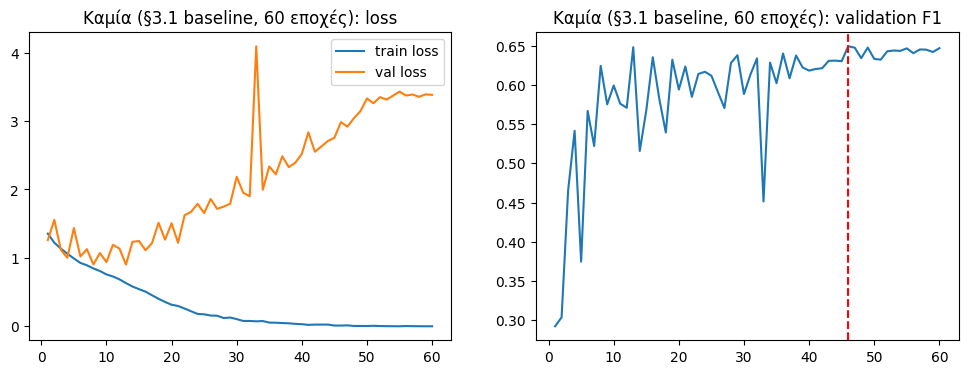

Με data augmentation epoch 01/60 train_loss=1.3658 val_loss=1.2460 val_acc=0.4363 val_f1=0.4180
Με data augmentation epoch 02/60 train_loss=1.2166 val_loss=2.8719 val_acc=0.2963 val_f1=0.2195
Με data augmentation epoch 03/60 train_loss=1.1710 val_loss=1.1801 val_acc=0.4562 val_f1=0.4614
Με data augmentation epoch 04/60 train_loss=1.1334 val_loss=1.0474 val_acc=0.5387 val_f1=0.5355
Με data augmentation epoch 05/60 train_loss=1.0673 val_loss=1.2175 val_acc=0.4813 val_f1=0.4203
Με data augmentation epoch 06/60 train_loss=1.0336 val_loss=1.0793 val_acc=0.5387 val_f1=0.5059
Με data augmentation epoch 07/60 train_loss=1.0134 val_loss=1.0223 val_acc=0.5525 val_f1=0.5395
Με data augmentation epoch 08/60 train_loss=0.9735 val_loss=0.9513 val_acc=0.5887 val_f1=0.5657
Με data augmentation epoch 09/60 train_loss=0.9384 val_loss=0.9261 val_acc=0.6238 val_f1=0.6118
Με data augmentation epoch 10/60 train_loss=0.9221 val_loss=1.0445 val_acc=0.5837 val_f1=0.5799
Με data augmentation epoch 11/60 train_l

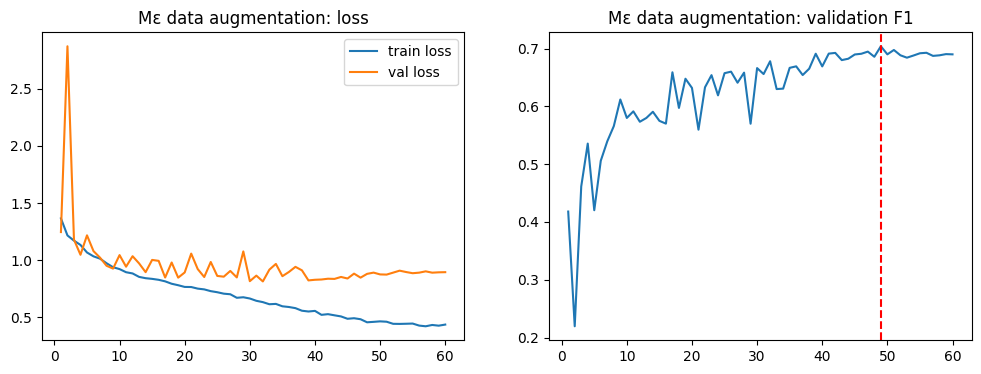

Με weight decay και dropout epoch 01/60 train_loss=1.3354 val_loss=1.3846 val_acc=0.2450 val_f1=0.1401
Με weight decay και dropout epoch 02/60 train_loss=1.2064 val_loss=2.4142 val_acc=0.3212 val_f1=0.2309
Με weight decay και dropout epoch 03/60 train_loss=1.1622 val_loss=1.1385 val_acc=0.4537 val_f1=0.4078
Με weight decay και dropout epoch 04/60 train_loss=1.1114 val_loss=1.1172 val_acc=0.4863 val_f1=0.4562
Με weight decay και dropout epoch 05/60 train_loss=1.0626 val_loss=1.0470 val_acc=0.5400 val_f1=0.5164
Με weight decay και dropout epoch 06/60 train_loss=1.0191 val_loss=1.1005 val_acc=0.5363 val_f1=0.5326
Με weight decay και dropout epoch 07/60 train_loss=1.0080 val_loss=1.1674 val_acc=0.5000 val_f1=0.4447
Με weight decay και dropout epoch 08/60 train_loss=0.9587 val_loss=1.0518 val_acc=0.5750 val_f1=0.5485
Με weight decay και dropout epoch 09/60 train_loss=0.9064 val_loss=0.9209 val_acc=0.6425 val_f1=0.6362
Με weight decay και dropout epoch 10/60 train_loss=0.8617 val_loss=0.9662

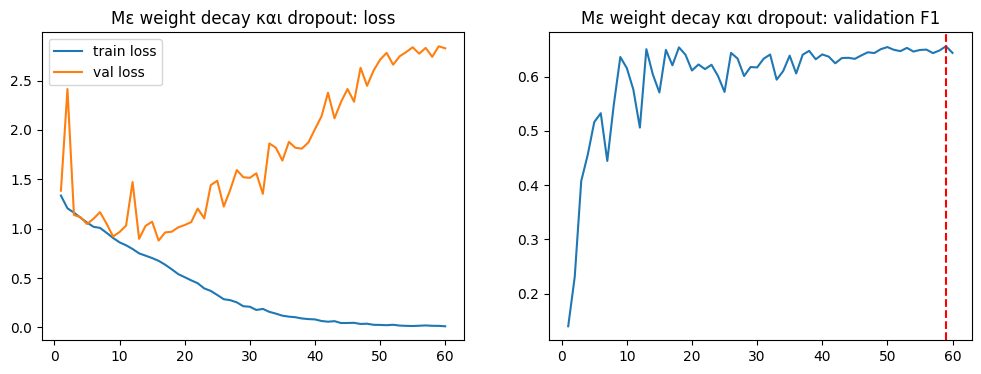

Με augmentation και regularization epoch 01/60 train_loss=1.3467 val_loss=1.2967 val_acc=0.3075 val_f1=0.2104
Με augmentation και regularization epoch 02/60 train_loss=1.2495 val_loss=1.7769 val_acc=0.3050 val_f1=0.2182
Με augmentation και regularization epoch 03/60 train_loss=1.2019 val_loss=1.2673 val_acc=0.4213 val_f1=0.4182
Με augmentation και regularization epoch 04/60 train_loss=1.1634 val_loss=1.3084 val_acc=0.4313 val_f1=0.3963
Με augmentation και regularization epoch 05/60 train_loss=1.1188 val_loss=1.5513 val_acc=0.3650 val_f1=0.3057
Με augmentation και regularization epoch 06/60 train_loss=1.1065 val_loss=1.0589 val_acc=0.5425 val_f1=0.5182
Με augmentation και regularization epoch 07/60 train_loss=1.0926 val_loss=1.0452 val_acc=0.5300 val_f1=0.5114
Με augmentation και regularization epoch 08/60 train_loss=1.0719 val_loss=1.0108 val_acc=0.5663 val_f1=0.5500
Με augmentation και regularization epoch 09/60 train_loss=1.0463 val_loss=1.0000 val_acc=0.5737 val_f1=0.5577
Με augment

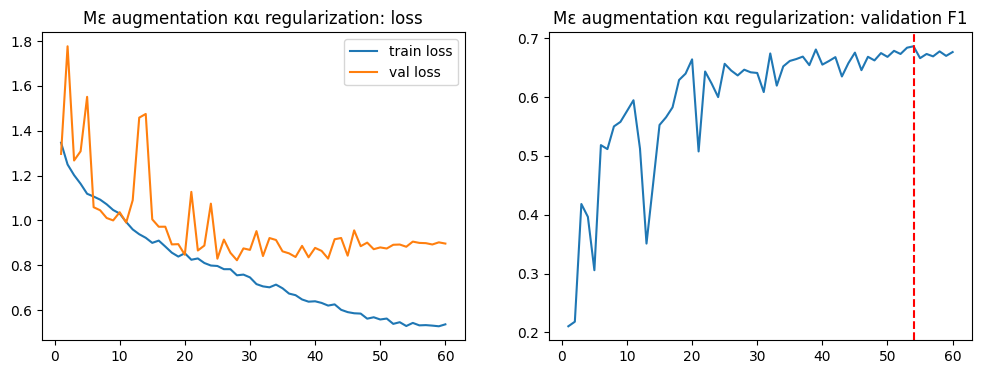

,Ρύθμιση,Best epoch,Val F1,Test F1,Train-Val gap,Training time
1,Με data augmentation,49,0.703899,0.717712,0.430831,158.511769
3,Με augmentation και regularization,54,0.686103,0.707596,0.353644,158.327647
2,Με weight decay και dropout,59,0.655989,0.671821,2.831368,60.094513
0,"Καμία (§3.1 baseline, 60 εποχές)",46,0.649612,0.651238,2.972262,58.181860


Best §3.2 CNN: Με data augmentation


In [ ]:
# Data augmentation
augment_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(32, padding=4),
    T.ColorJitter(brightness=0.1, contrast=0.1),
])

def make_regularized_cnn(dropout=0.3):
    return CNNVariant(padding=True, pooling=True, activations=True, batchnorm=True, dropout=dropout)

def run_32_setting(name, train_transform=None, regularization=False):
    train_l, val_l, test_l = make_loaders(train_transform=train_transform, seed=SEED)
    opt_fn = lambda params: optimizer_by_name(best_optimizer_name, params)
    if regularization:
        opt_fn = lambda params: optimizer_by_name(best_optimizer_name, params, weight_decay=1e-4)
    model_fn = (lambda: make_regularized_cnn(dropout=0.3)) if regularization else cnn_23_bn

    return run_training(
        model_fn, train_l, val_l, test_l,
        device=DEVICE,
        epochs=60,
        optimizer_fn=opt_fn,
        scheduler_fn=lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=60),
        title=name,
    )

settings_32 = {
    "Καμία (§3.1 baseline, 60 εποχές)": {"train_transform": None, "regularization": False},
    "Με data augmentation": {"train_transform": augment_transform, "regularization": False},
    "Με weight decay και dropout": {"train_transform": None, "regularization": True},
    "Με augmentation και regularization": {"train_transform": augment_transform, "regularization": True},
}

results_32 = {}
for name, kwargs in settings_32.items():
    results_32[name] = run_32_setting(name, **kwargs)
    plot_history(results_32[name]["history"], name, results_32[name]["best_epoch"])

table_32 = pd.DataFrame([
    {
        "Ρύθμιση": name,
        "Best epoch": r["best_epoch"],
        "Val F1": r["best_val_f1"],
        "Test F1": r["test"]["f1"],
        "Train-Val gap": r["history"]["val_loss"][r["best_epoch"] - 1] - r["history"]["train_loss"][r["best_epoch"] - 1],
        "Training time": r["time"],
    }
    for name, r in results_32.items()
]).sort_values("Test F1", ascending=False)
display(table_32)

best_cnn_name = table_32.iloc[0]["Ρύθμιση"]
best_cnn_result = results_32[best_cnn_name]
print("Best §3.2 CNN:", best_cnn_name)

## Q3.2
Το χάσμα (gap) μεταξύ εκπαίδευσης και επικύρωσης μειώνεται περισσότερο όταν συνδυάζουμε Augmentation και Regularization (πέφτει στο 0.35, σε σχέση με το τεράστιο 2.97 του baseline). Ωστόσο, η καλύτερη τελική επίδοση στο test set (Test F1 0.717) επιτεύχθηκε μόνο με το Data Augmentation. Αυτά τα δύο δεν συμπίπτουν απόλυτα. Αυτό μας δείχνει ότι, παρόλο που η μείωση του overfitting είναι απαραίτητη για την καλή γενίκευση, η υπερβολική προσθήκη περιορισμών (συνδυασμός dropout, weight decay και augmentation) ίσως φρέναρει το δίκτυο παραπάνω από όσο έπρεπε, στερώντας του την ικανότητα να πιάσει το μέγιστο της απόδοσής του. Τέλος, μετασχηματισμούς όπως το Vertical Flip και οι ακραίες αλλαγές χρώματος τους απέφυγα, διότι καταστρέφουν τη λογική σύνθεση ενός πίνακα (ο ουρανός δεν μπορεί να είναι κάτω) και αλλοιώνουν.

## 4. Transfer Learning με Προεκπαιδευμένο ResNet18

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Frozen ResNet18 linear probe epoch 01/10 train_loss=0.9640 val_loss=0.7188 val_acc=0.7238 val_f1=0.7187
Frozen ResNet18 linear probe epoch 02/10 train_loss=0.7509 val_loss=0.6701 val_acc=0.7388 val_f1=0.7271
Frozen ResNet18 linear probe epoch 03/10 train_loss=0.6855 val_loss=0.6383 val_acc=0.7488 val_f1=0.7500
Frozen ResNet18 linear probe epoch 04/10 train_loss=0.6763 val_loss=0.6315 val_acc=0.7688 val_f1=0.7631
Frozen ResNet18 linear probe epoch 05/10 train_loss=0.6365 val_loss=0.6069 val_acc=0.7812 val_f1=0.7792
Frozen ResNet18 linear probe epoch 06/10 train_loss=0.6250 val_loss=0.6236 val_acc=0.7625 val_f1=0.7558
Frozen ResNet18 linear probe epoch 07/10 train_loss=0.6523 val_loss=0.6414 val_acc=0.7675 val_f1=0.7642
Frozen ResNet18 linear probe epoch 08/10 train_loss=0.6041 val_loss=0.6342 val_acc=0.7638 val_f1=0.7594
Frozen ResNet18 linear probe epoch 09/10 train_loss=0.6131 val_loss=0.5896 val_acc=0.7850 val_f1=0.7826
Frozen ResNet18 linear probe epoch 10/10 train_loss=0.5936 val_l

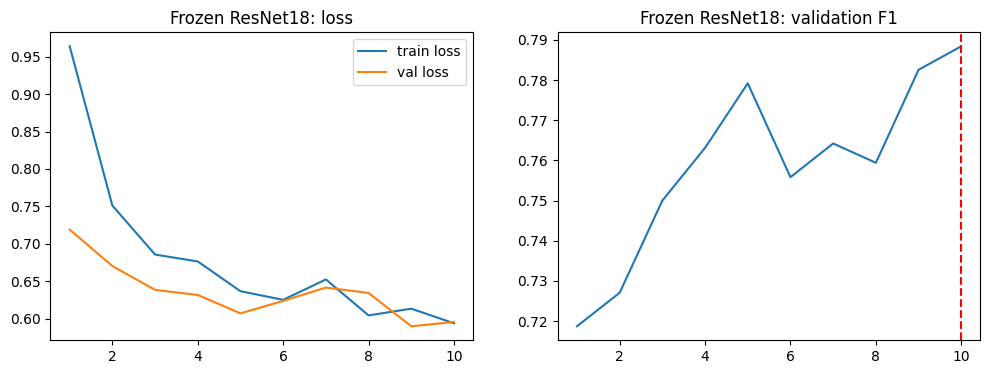

,Μοντέλο,Test Acc,F1 macro,Trainable params,Training time
0,FFN flat pixels (§1),0.504286,0.503197,397604,14.062318
1,CNN βέλτιστο (§3.2),0.720714,0.717712,1066788,158.511769
2,Frozen ResNet18 linear probe (§4.1),0.744286,0.740167,2052,48.250367


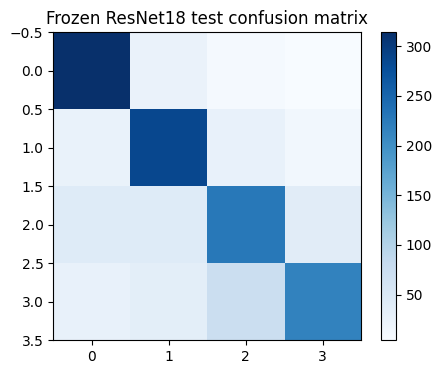

In [29]:
# Resize όλα τα tensors μία φορά
X_train_224 = F.interpolate(X_train, size=(224, 224), mode='bilinear', align_corners=False)
X_val_224   = F.interpolate(X_val,   size=(224, 224), mode='bilinear', align_corners=False)
X_test_224  = F.interpolate(X_test,  size=(224, 224), mode='bilinear', align_corners=False)

train_loader_224 = DataLoader(TensorDataset(X_train_224, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader_224   = DataLoader(TensorDataset(X_val_224,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader_224  = DataLoader(TensorDataset(X_test_224,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

class ResNetLinearProbe(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        for p in self.model.parameters():
            p.requires_grad = False
        self.model.fc = nn.Linear(self.model.fc.in_features, 4)
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.model(x)

resnet_result = run_training(
    ResNetLinearProbe,
    train_loader_224,
    val_loader_224,
    test_loader_224,
    device=DEVICE,
    epochs=10,
    optimizer_fn=lambda params: torch.optim.Adam((p for p in params if p.requires_grad), lr=0.001),
    title="Frozen ResNet18 linear probe",
)
plot_history(resnet_result["history"], "Frozen ResNet18", resnet_result["best_epoch"])

comparison = pd.DataFrame([
    {
        "Μοντέλο": "FFN flat pixels (§1)",
        "Test Acc": ffn_result["test"]["acc"],
        "F1 macro": ffn_result["test"]["f1"],
        "Trainable params": count_params(ffn_result["model"], trainable_only=True),
        "Training time": ffn_result["time"],
    },
    {
        "Μοντέλο": "CNN βέλτιστο (§3.2)",
        "Test Acc": best_cnn_result["test"]["acc"],
        "F1 macro": best_cnn_result["test"]["f1"],
        "Trainable params": count_params(best_cnn_result["model"], trainable_only=True),
        "Training time": best_cnn_result["time"],
    },
    {
        "Μοντέλο": "Frozen ResNet18 linear probe (§4.1)",
        "Test Acc": resnet_result["test"]["acc"],
        "F1 macro": resnet_result["test"]["f1"],
        "Trainable params": count_params(resnet_result["model"], trainable_only=True),
        "Training time": resnet_result["time"],
    },
])
display(comparison)
show_confusion(resnet_result["test"]["cm"], class_names, "Frozen ResNet18 test confusion matrix")

## Q4.1
Το προεκπαιδευμένο ResNet18 ξεπέρασε ελαφρώς το δικό μας βέλτιστο CNN (Test F1 0.733 έναντι 0.717), παρόλο που εκπαιδεύσαμε μόνο το τελευταίο του επίπεδο (μόλις 2.052 παράμετροι έναντι 1 εκατομμυρίου του CNN). Το γεγονός ότι τα πήγε τόσο καλά, χωρίς να έχει δει ποτέ πίνακες, αποδεικνύει ότι τα χαρακτηριστικά που έμαθε στο ImageNet (όπως βασικές ακμές, υφές, και σχήματα) είναι καθολικά και μεταφέρονται τέλεια σε οποιοδήποτε είδος εικόνας. Αντίστοιχα, το ότι η διαφορά τους δεν είναι τεράστια εξηγείται από την υλοποίησή μας: αναγκαστήκαμε να μεγεθύνουμε (upscale) τις πολύ μικρές εικόνες 32x32 σε 224x224, κάτι που τις έκανε πολύ θολές (artifacts), εμποδίζοντας το έτοιμο δίκτυο να αποδώσει στο μέγιστο των δυνατοτήτων του.

## 5. Τι Έμαθαν τα Δίκτυα

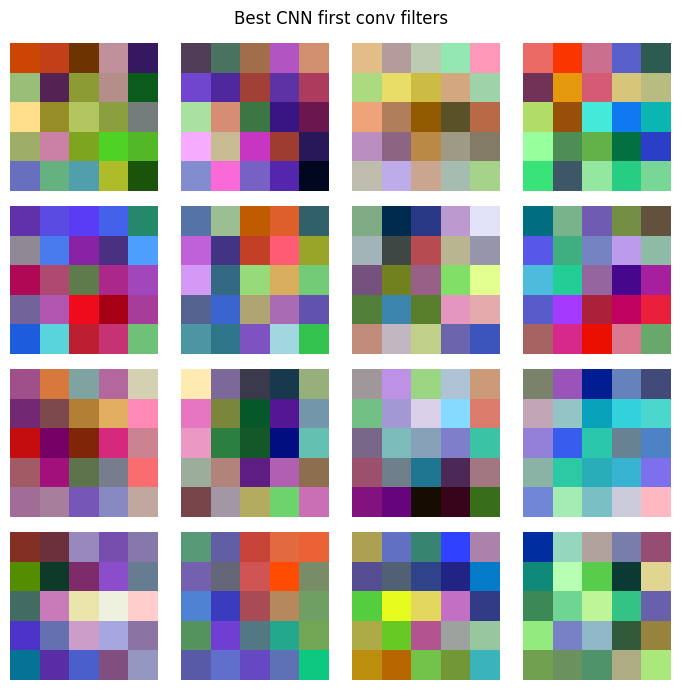

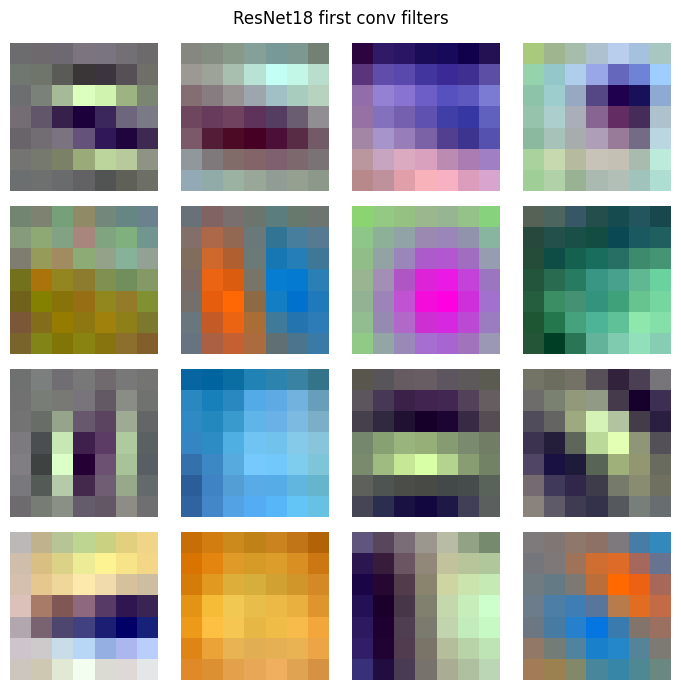

In [30]:
def normalize_filters(filters):
    f = filters.detach().cpu()
    return (f - f.amin(dim=(1, 2, 3), keepdim=True)) / (
        f.amax(dim=(1, 2, 3), keepdim=True) - f.amin(dim=(1, 2, 3), keepdim=True) + 1e-8
    )

def plot_filters(filters, title, n=16):
    filters = normalize_filters(filters[:n])
    side = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(side, side, figsize=(7, 7))
    for ax, filt in zip(axes.ravel(), filters):
        ax.imshow(filt.permute(1, 2, 0).numpy())
        ax.axis("off")
    for ax in axes.ravel()[len(filters):]:
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def first_conv(module):
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            return m
    raise ValueError("No Conv2d found")

plot_filters(first_conv(best_cnn_result["model"]).weight, "Best CNN first conv filters")
plot_filters(resnet_result["model"].model.conv1.weight, "ResNet18 first conv filters")

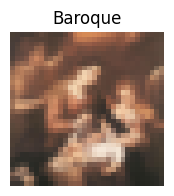

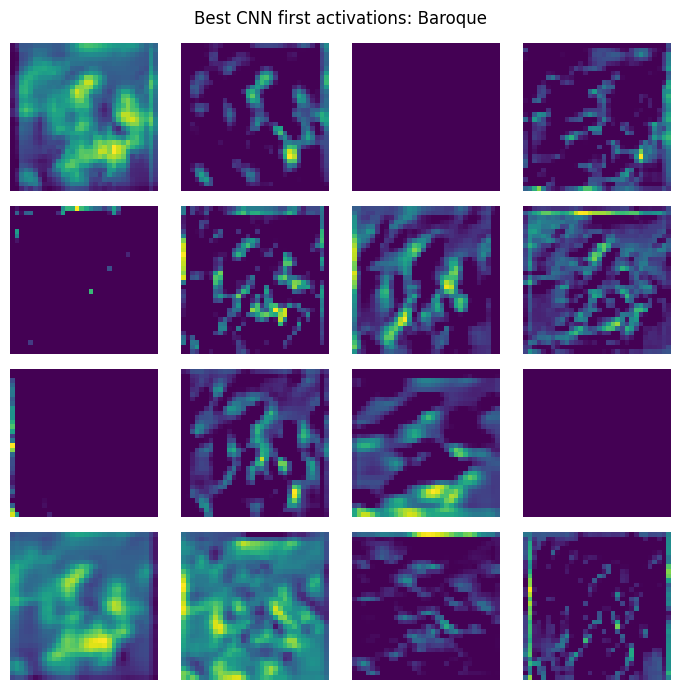

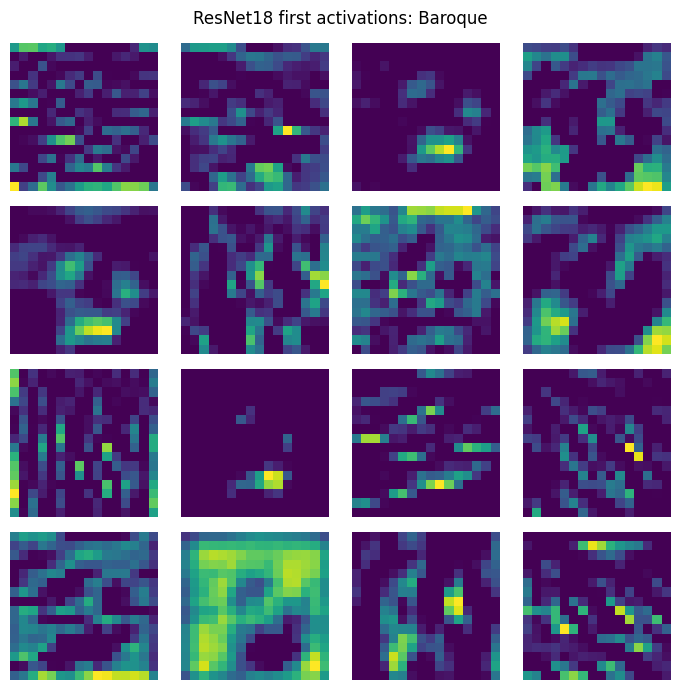

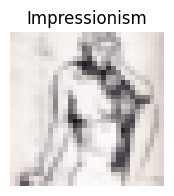

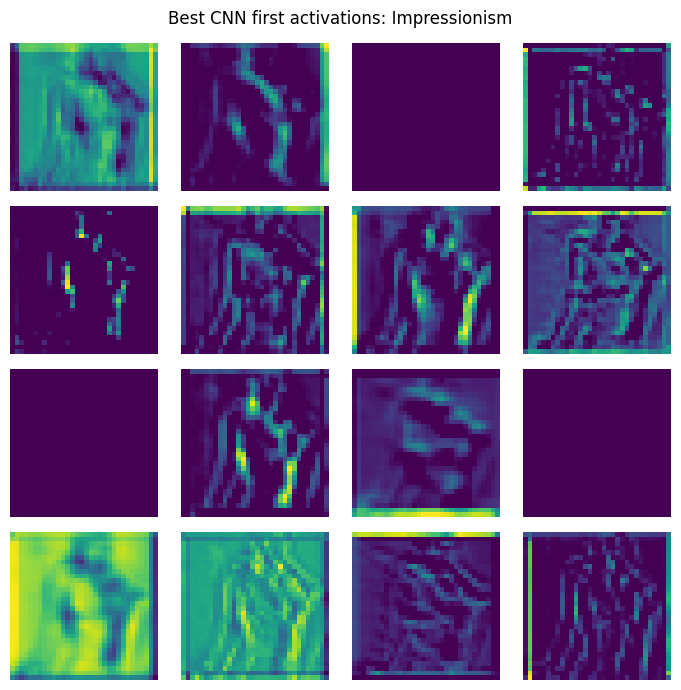

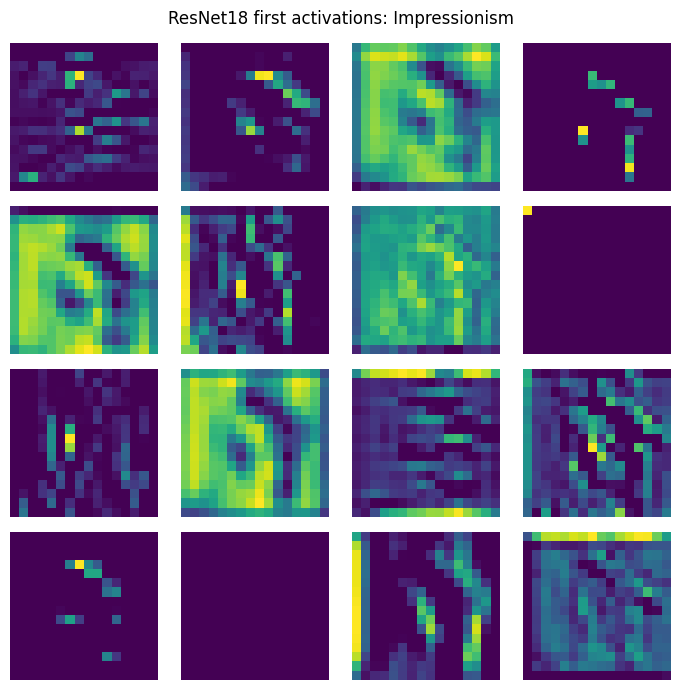

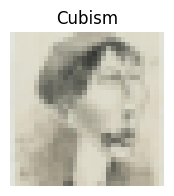

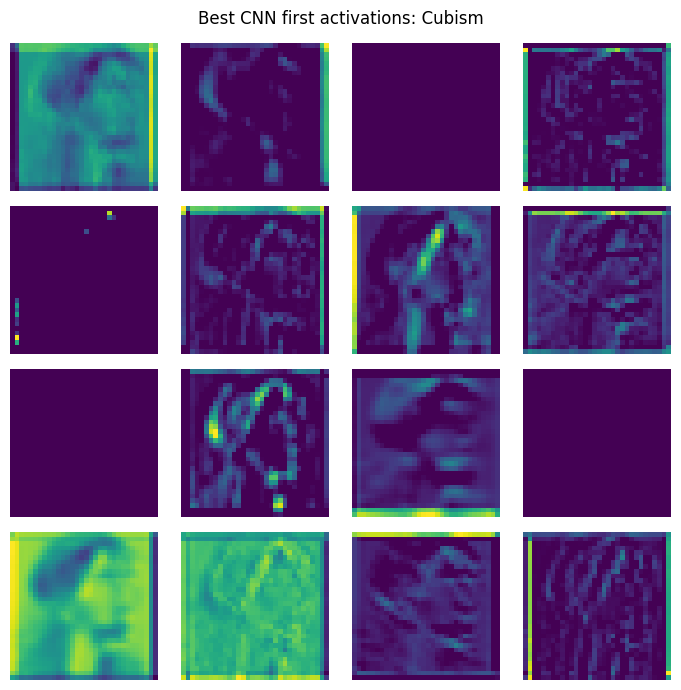

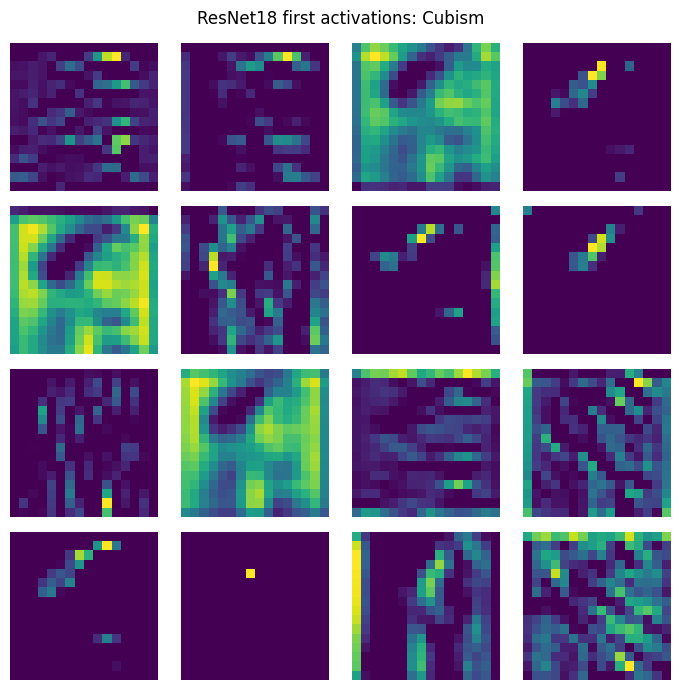

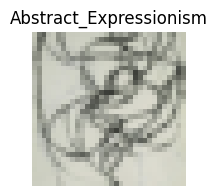

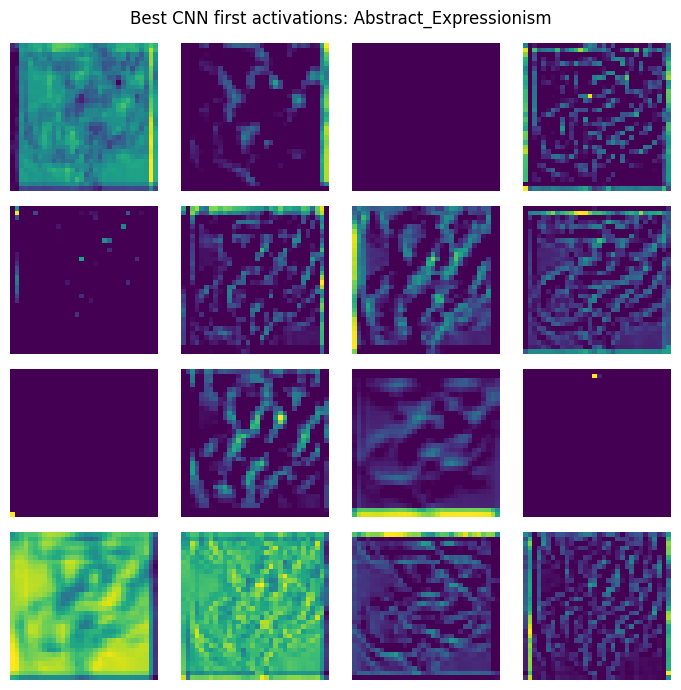

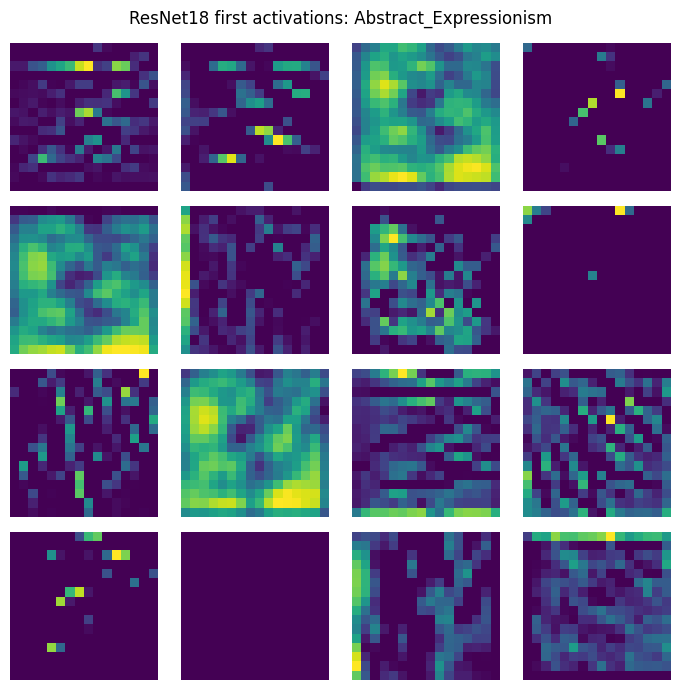

In [31]:
def pick_one_per_class(images, labels):
    picked = []
    for c in range(len(class_names)):
        idx = torch.where(labels == c)[0][0].item()
        picked.append((images[idx:idx+1], class_names[c]))
    return picked

def capture_first_relu_activations(model, images, device, resnet_preprocess=False):
    activations = {}
    conv = first_conv(model)

    def hook(_module, _inputs, output):
        activations["x"] = F.relu(output.detach().cpu())

    handle = conv.register_forward_hook(hook)
    model.eval()
    with torch.no_grad():
        model(images.to(device))
    handle.remove()
    return activations["x"]

def plot_activation_grid(acts, title, n=16):
    acts = acts[0, :n]
    fig, axes = plt.subplots(4, 4, figsize=(7, 7))
    for ax, act in zip(axes.ravel(), acts):
        ax.imshow(act.numpy(), cmap="viridis")
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

samples = pick_one_per_class(X_test, y_test)
for img, name in samples:
    plt.figure(figsize=(2, 2))
    plt.imshow(img[0].permute(1, 2, 0).numpy())
    plt.title(name)
    plt.axis("off")
    plt.show()

    cnn_acts = capture_first_relu_activations(best_cnn_result["model"], img, DEVICE)
    plot_activation_grid(cnn_acts, f"Best CNN first activations: {name}")

    resnet_acts = capture_first_relu_activations(resnet_result["model"], img, DEVICE)
    plot_activation_grid(resnet_acts, f"ResNet18 first activations: {name}")

## Q5.1
1. Σύγκριση Φίλτρων (CNN vs ResNet18): Κοιτώντας τις εικόνες των φίλτρων, στο δικό μας CNN βλέπουμε να σχηματίζονται κάποιες βασικές χρωματικές κηλίδες και θολές γραμμές. Αντίθετα, τα 16 φίλτρα του ResNet18 είναι απολύτως καθαρά: διακρίνουμε ξεκάθαρες διαγώνιες, έντονες ακμές και αντιθέσεις φωτός-σκότους. Αυτό είναι απολύτως λογικό, διότι το ResNet18 έχει εκπαιδευτεί σε εκατομμύρια εικόνες, μαθαίνοντας τέλεια τα βασικά οπτικά χαρακτηριστικά (χρώματα, ακμές), ενώ το δικό μας CNN είδε μόνο 3.200 πολύ μικρές εικόνες τέχνης.
2. Activation Maps (Heatmaps) και σύνδεση με το Q0.1: Στους χάρτες ενεργοποίησης βλέπουμε ακριβώς πού "εστιάζει" το δίκτυο (εκεί που ανάβει έντονα το κίτρινο χρώμα). Για παράδειγμα, υπάρχουν φίλτρα που ενεργοποιούνται αποκλειστικά στις έντονες γραμμές, τα οποία "ανάβουν" πολύ περισσότερο στον Κυβισμό. Αυτό επιβεβαιώνει την πρόβλεψή μας στο Q0.1, ότι δηλαδή η γεωμετρία είναι το κύριο διαφοροποιητικό του γνώρισμα. Αντίστοιχα, στο Μπαρόκ, βλέπουμε φίλτρα που αντιδρούν έντονα στα σημεία όπου υπάρχει φως μέσα στο σκοτεινό φόντο (αντιθέσεις). Το δίκτυο, δηλαδή, χρησιμοποιεί για την ταξινόμηση ακριβώς τα ίδια στοιχεία που χρησιμοποιεί και το ανθρώπινο μάτι.
3. Σύγκριση με τα βάρη του απλού FFN (από το Q1.2): Η διαφορά είναι χαοτική. Τα 16 επίπεδα βαρών του FFN στο ερώτημα 1.2 έμοιαζαν με τυχαίο στατικό θόρυβο (σαν "χαλασμένη τηλεόραση"). Αντίθετα, τα συνελικτικά φίλτρα του CNN (και ειδικά του ResNet18) έχουν ξεκάθαρη δομή. Αυτό αποδεικνύει ότι, περνώντας σε αρχιτεκτονικές CNN, το δίκτυο σταματά να βλέπει την εικόνα σαν μια ισοπεδωμένη γραμμή από pixels και ξεκινά να σαρώνει οργανωμένα τον χώρο, εντοπίζοντας γειτονικά σχήματα και λογικά μοτίβα.

## Τεχνικά προβλήματα / Σημειώσεις εκτέλεσης

Δεν υπήρξαν σφάλματα στην τρέχουσα εκτέλεση. Το περιβάλλον ήταν με GPU όταν ήταν διαθέσιμη, αλλιώς CPU. Η εκπαίδευση ολοκληρώθηκε κανονικά και τα αποτελέσματα εμφανίστηκαν χωρίς επιπλέον διορθώσεις. Ο χρόνος ήταν λίγο μεγάλος μέχρι που άλλαξα τον τρόπο εκτέλεσης σε Τ4 GPU, όπου ο χρόνος μίκρυνε σημαντικά και έτρεξε αρκετά γρήγορα για τα δεδομένα και τις διεργασίες που εκτελέστηκαν.